# **CONTOH PERHITUNGAN AUC**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
y_true = ['Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Rendah',
          'Sedang', 'Tinggi', 'Rendah', 'Sedang', 'Tinggi']

y_prob = np.array([
    [0.70, 0.15, 0.15],  # s1
    [0.55, 0.30, 0.15],  # s2
    [0.30, 0.55, 0.15],  # s3
    [0.10, 0.20, 0.70],  # s4
    [0.60, 0.30, 0.10],  # s5
    [0.15, 0.70, 0.15],  # s6
    [0.15, 0.60, 0.25],  # s7
    [0.40, 0.40, 0.20],  # s8
    [0.35, 0.40, 0.25],  # s9
    [0.45, 0.15, 0.40],  # s10
])

kelas = ['Rendah', 'Sedang', 'Tinggi']
warna = ['#2196F3', '#FF9800', '#4CAF50']

In [ ]:
# KONVERSI LABEL KE ANGKA & BINARISASI (One-vs-Rest)

y_true_idx = np.array([kelas.index(l) for l in y_true])
Y_bin = label_binarize(y_true_idx, classes=[0, 1, 2])

In [ ]:
# HITUNG ROC & AUC PER KELAS

fpr = {}
tpr = {}
auc_val = {}

print("  HASIL AUC PER KELAS (One-vs-Rest)")

for i, nama in enumerate(kelas):
    fpr[i], tpr[i], _ = roc_curve(Y_bin[:, i], y_prob[:, i])
    auc_val[i] = auc(fpr[i], tpr[i])
    print(f"  AUC {nama:8s} = {auc_val[i]:.4f}")

macro_auc = np.mean(list(auc_val.values()))

print(f"  Macro-Average AUC = {macro_auc:.4f}")

  HASIL AUC PER KELAS (One-vs-Rest)
  AUC Rendah   = 0.9583
  AUC Sedang   = 0.8810
  AUC Tinggi   = 0.9762
  Macro-Average AUC = 0.9385


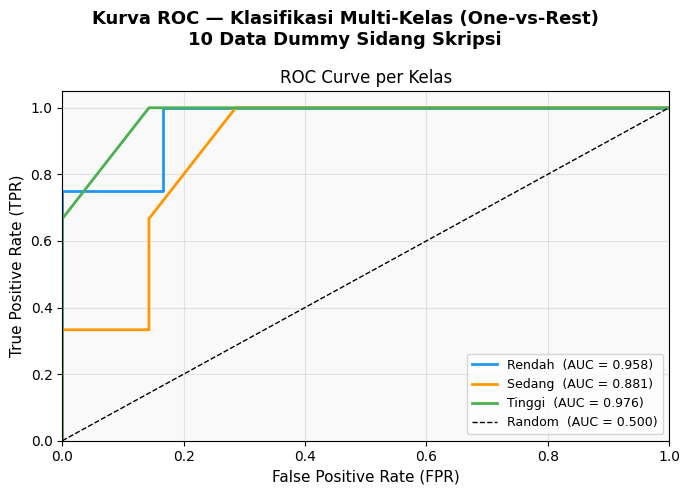


Grafik tersimpan: roc_auc_hasil.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle("Kurva ROC — Klasifikasi Multi-Kelas (One-vs-Rest)\n10 Data Dummy Sidang Skripsi",
             fontsize=13, fontweight='bold')

for i, nama in enumerate(kelas):
    ax.plot(fpr[i], tpr[i],
            color=warna[i], linewidth=2,
            label=f"{nama}  (AUC = {auc_val[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random  (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ROC Curve per Kelas')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('roc_auc_hasil.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGrafik tersimpan: roc_auc_hasil.png")